# 53 - Intermediate TL conf60 7-class

**Dataset:** Front-only conf60 (confidence >= 60%)
**Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import IntermediateFusionTransfer
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly_conf60" / "7class_tl"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.00005
PATIENCE = 15
NUM_CLASSES = 7
EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]

print(f"Dataset: {DATASET_DIR}")
print(f"Dataset Aug: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Device: cuda
GPU: Tesla T4
Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60
Dataset Aug: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class_tl


In [2]:
def load_dataloaders(dataset_dir, batch_size=32):
    loaders = {}
    for split in ["train", "val", "test"]:
        ds = EmotionMultimodalDataset(dataset_dir / f"X_{split}_images.npy", dataset_dir / f"X_{split}_landmarks.npy", dataset_dir / f"y_{split}.npy")
        loaders[split] = DataLoader(ds, batch_size=batch_size, shuffle=(split=="train"), num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(y)} | Val: {len(np.load(dataset_dir / 'y_val.npy'))} | Test: {len(np.load(dataset_dir / 'y_test.npy'))}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return loaders["train"], loaders["val"], loaders["test"]

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 5287 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
       angry: 27
     fearful: 2
   disgusted: 13
   surprised: 16


## Training B1, B2, B3


Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.5107     0.5130     1.3885    0.8238   0.1291   0.000050  (19.2s)


     2      0.8802     0.8311     1.1238    0.8221   0.1388   0.000050  (18.9s)


     3      0.5983     0.8663     0.9206    0.8256   0.2019   0.000050  (18.9s)


     4      0.4642     0.8861     0.8329    0.8169   0.2512   0.000050  (18.8s)


...

    15      0.0863     0.9845     0.7314    0.8152   0.1856   0.000025  (18.5s)


    16      0.0855     0.9841     0.8226    0.8273   0.1640   0.000025  (18.4s)


    17      0.0753     0.9864     0.7646    0.8290   0.1673   0.000025  (18.4s)


    18      0.0719     0.9879     0.7530    0.8221   0.1710   0.000025  (18.3s)


    19      0.0703     0.9871     0.7941    0.8273   0.1703   0.000025  (18.2s)

Early stopping at epoch 19. Best epoch: 4 (val_f1=0.2512)

Best: epoch 4, val_acc=0.8169, val_f1=0.2512
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class_tl/intermediate_tl_b1.pth


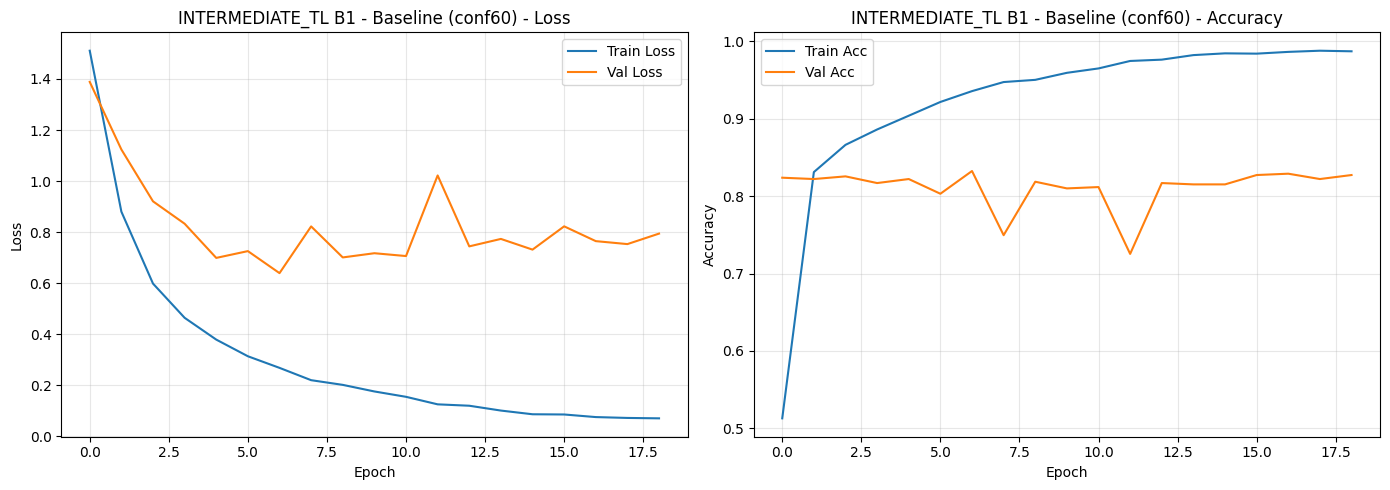

Test Loss: 0.7966
Test Accuracy: 0.7922
Test Macro F1: 0.2769
Test Weighted F1: 0.7997

Classification Report:
              precision    recall  f1-score   support

     neutral       0.91      0.84      0.87       688
       happy       0.61      0.74      0.67       183
         sad       0.33      0.50      0.40        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.79       929
   macro avg       0.26      0.30      0.28       929
weighted avg       0.81      0.79      0.80       929



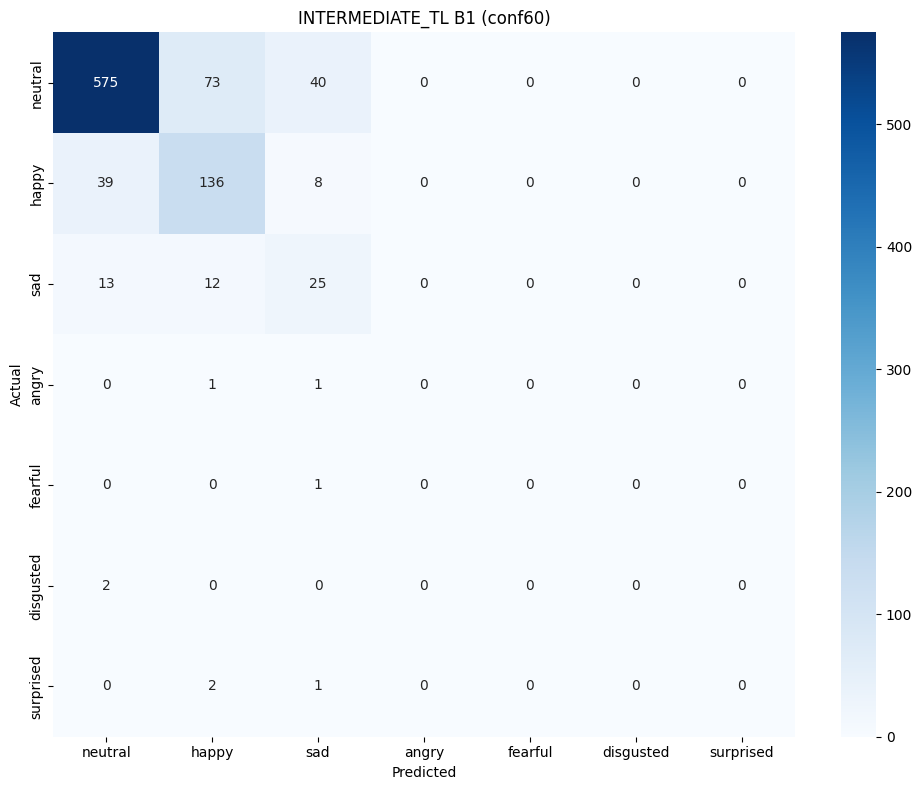

B1: Acc=0.7922 F1=0.2769

Class weights: None


Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.6776     0.3947     1.3383    0.8221   0.1585   0.000050  (18.2s)


     2      0.9279     0.8180     0.9578    0.8221   0.1665   0.000050  (18.1s)


     3      0.6066     0.8752     0.8194    0.8325   0.2392   0.000050  (18.3s)


...

    14      0.1029     0.9813     0.7136    0.8307   0.1744   0.000025  (18.1s)


    15      0.0903     0.9856     0.6922    0.8256   0.1860   0.000025  (18.2s)


    16      0.0923     0.9841     0.7155    0.8394   0.2315   0.000025  (18.2s)


    17      0.0852     0.9830     0.7113    0.8377   0.2178   0.000025  (18.1s)


    18      0.0781     0.9854     0.6871    0.8187   0.2125   0.000025  (18.2s)

Early stopping at epoch 18. Best epoch: 3 (val_f1=0.2392)

Best: epoch 3, val_acc=0.8325, val_f1=0.2392
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class_tl/intermediate_tl_b2.pth


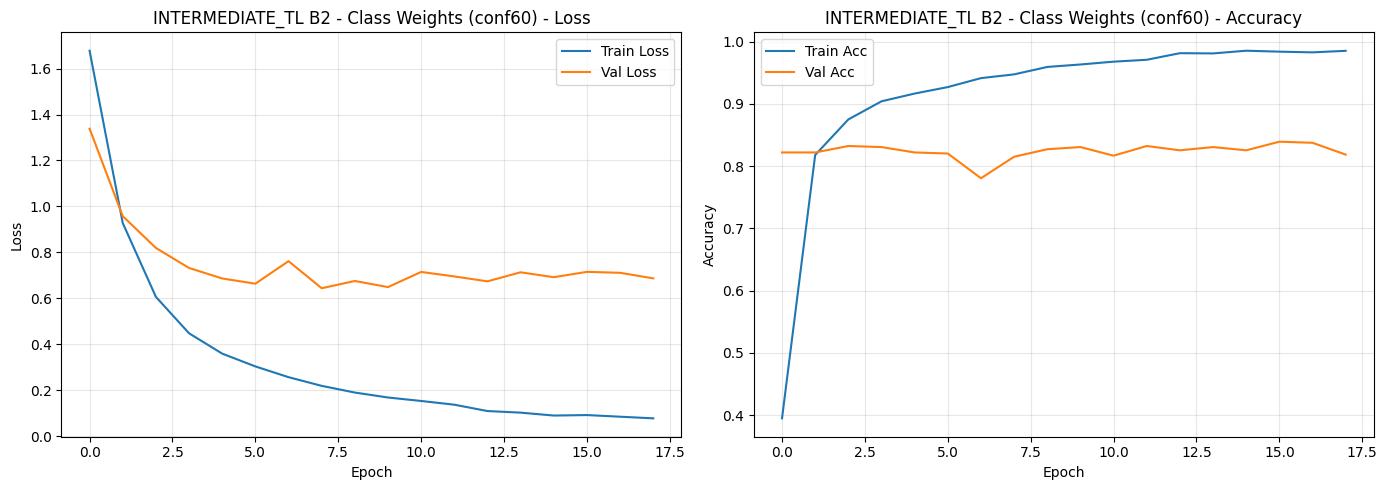

Test Loss: 0.7789
Test Accuracy: 0.8245
Test Macro F1: 0.2833
Test Weighted F1: 0.8249

Classification Report:
              precision    recall  f1-score   support

     neutral       0.89      0.89      0.89       688
       happy       0.76      0.71      0.73       183
         sad       0.31      0.42      0.36        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.82       929
   macro avg       0.28      0.29      0.28       929
weighted avg       0.83      0.82      0.82       929



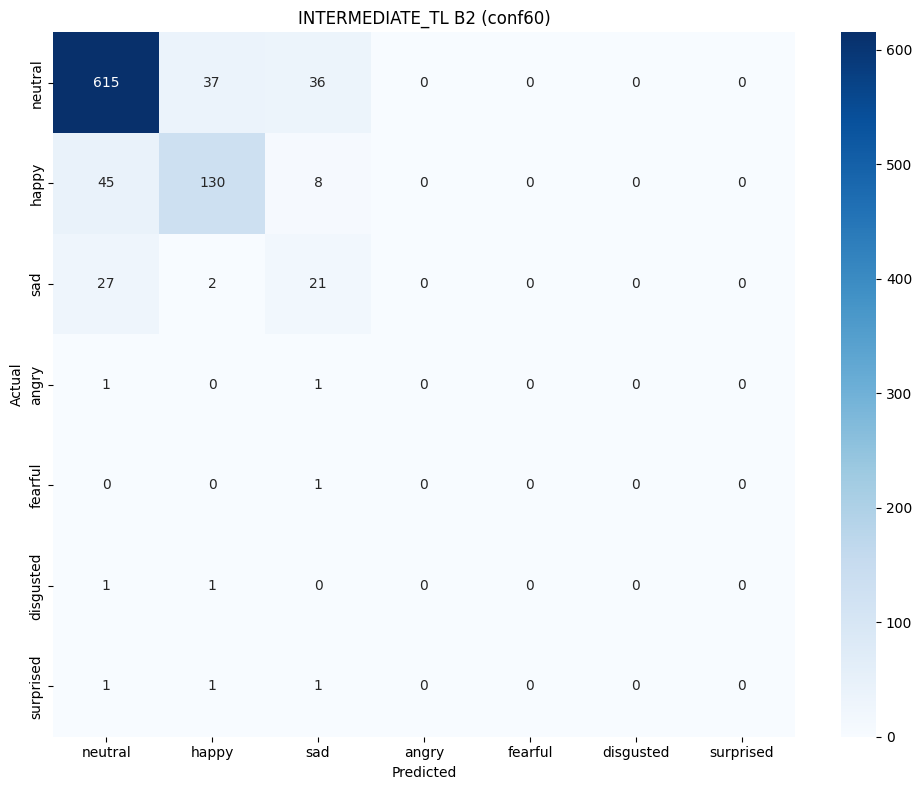

B2: Acc=0.8245 F1=0.2833


Train: 5829 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150



Training B3 (class weights + augmented)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.7054     0.3858     1.3333    0.8135   0.1554   0.000050  (20.6s)


     2      1.0089     0.7694     0.9508    0.8359   0.2073   0.000050  (20.9s)


...

    15      0.0648     0.9940     0.9317    0.8273   0.1906   0.000025  (20.8s)


    16      0.0586     0.9938     0.9408    0.8204   0.1616   0.000025  (20.8s)


    17      0.0476     0.9959     1.0083    0.8238   0.1706   0.000025  (20.8s)


    18      0.0466     0.9967     0.9885    0.8256   0.1671   0.000025  (20.9s)


    19      0.0504     0.9935     0.9968    0.8152   0.1620   0.000025  (20.8s)

Early stopping at epoch 19. Best epoch: 4 (val_f1=0.2136)

Best: epoch 4, val_acc=0.8411, val_f1=0.2136
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class_tl/intermediate_tl_b3.pth


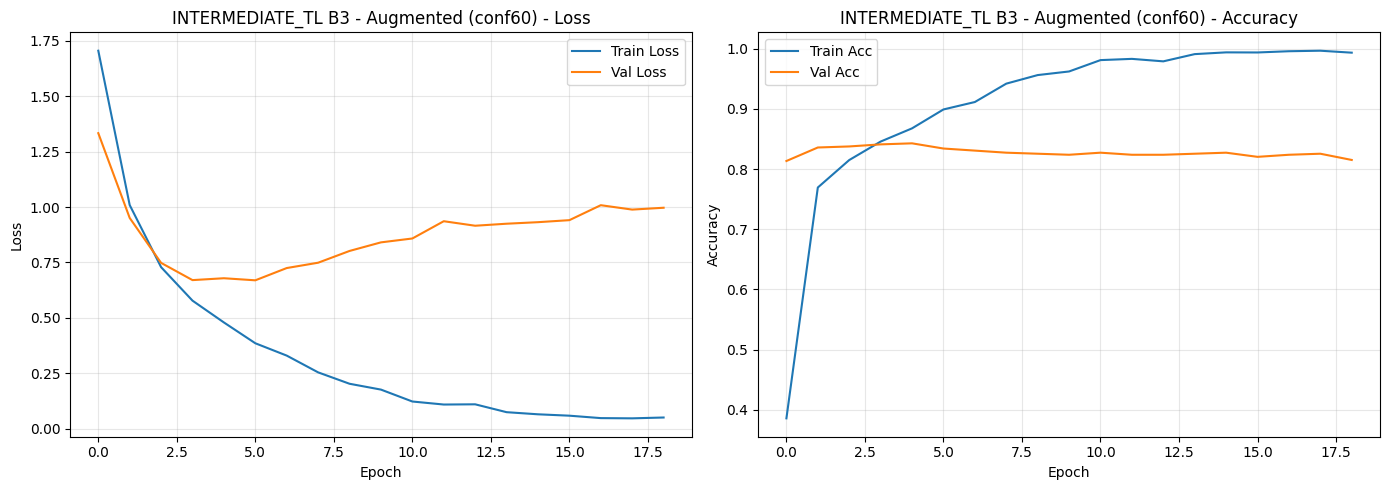

Test Loss: 0.7098
Test Accuracy: 0.8245
Test Macro F1: 0.2917
Test Weighted F1: 0.8256

Classification Report:
              precision    recall  f1-score   support

     neutral       0.90      0.88      0.89       688
       happy       0.72      0.73      0.72       183
         sad       0.37      0.50      0.43        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.82       929
   macro avg       0.28      0.30      0.29       929
weighted avg       0.83      0.82      0.83       929



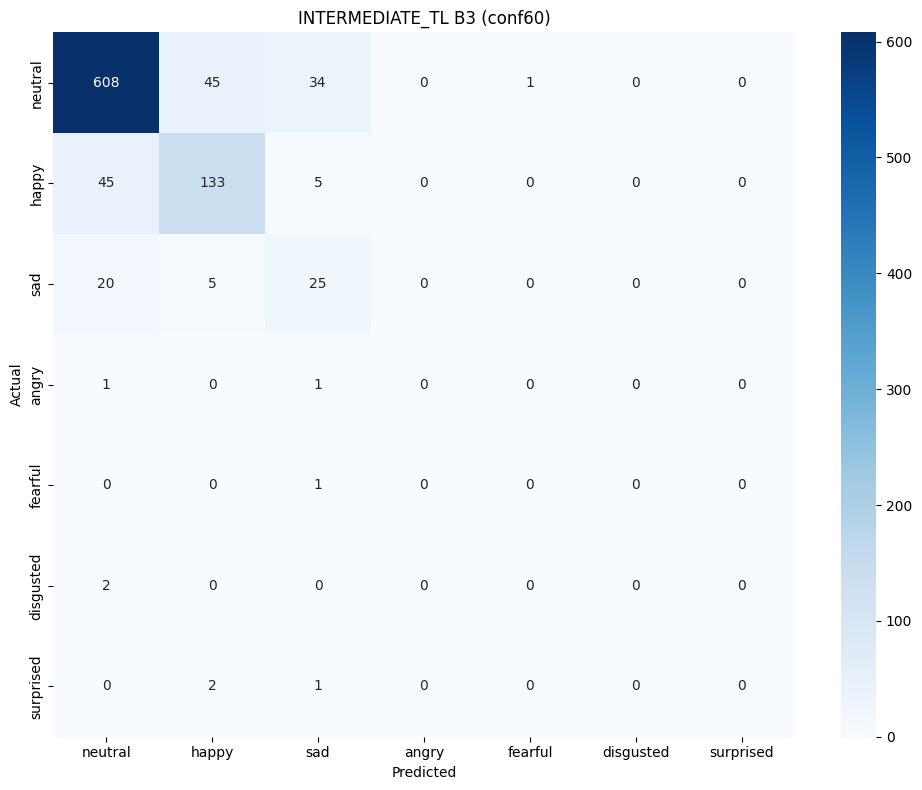

B3: Acc=0.8245 F1=0.2917

RINGKASAN INTERMEDIATE_TL (conf60)
  B1 Baseline               Acc=0.7922 F1=0.2769
  B2 Class Weights          Acc=0.8245 F1=0.2833
  B3 Weights+Aug            Acc=0.8245 F1=0.2917

Saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class_tl/intermediate_tl_results.json


In [3]:
all_results = {}

# B1: Baseline
model_b1 = IntermediateFusionTransfer(num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B1 (baseline)...")
history_b1, _ = train_model(model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "intermediate_tl_b1.pth"))
plot_training_history(history_b1, "INTERMEDIATE_TL B1 - Baseline (conf60)")
model_b1.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_tl_b1.pth", map_location=device, weights_only=True))
r_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "fusion", EMOTIONS)
plot_confusion_matrix(r_b1["confusion_matrix"], "INTERMEDIATE_TL B1 (conf60)", EMOTIONS)
all_results["B1 Baseline"] = {"accuracy": float(r_b1["test_accuracy"]), "macro_f1": float(r_b1["test_macro_f1"]), "weighted_f1": float(r_b1["test_weighted_f1"])}
print(f"B1: Acc={r_b1['test_accuracy']:.4f} F1={r_b1['test_macro_f1']:.4f}")

# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"\nClass weights: {weights}")
model_b2 = IntermediateFusionTransfer(num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("Training B2 (class weights)...")
history_b2, _ = train_model(model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "intermediate_tl_b2.pth"))
plot_training_history(history_b2, "INTERMEDIATE_TL B2 - Class Weights (conf60)")
model_b2.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_tl_b2.pth", map_location=device, weights_only=True))
r_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "fusion", EMOTIONS)
plot_confusion_matrix(r_b2["confusion_matrix"], "INTERMEDIATE_TL B2 (conf60)", EMOTIONS)
all_results["B2 Class Weights"] = {"accuracy": float(r_b2["test_accuracy"]), "macro_f1": float(r_b2["test_macro_f1"]), "weighted_f1": float(r_b2["test_weighted_f1"])}
print(f"B2: Acc={r_b2['test_accuracy']:.4f} F1={r_b2['test_macro_f1']:.4f}")

# B3: Class Weights + Augmented
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
model_b3 = IntermediateFusionTransfer(num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B3 (class weights + augmented)...")
history_b3, _ = train_model(model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "intermediate_tl_b3.pth"))
plot_training_history(history_b3, "INTERMEDIATE_TL B3 - Augmented (conf60)")
model_b3.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_tl_b3.pth", map_location=device, weights_only=True))
r_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "fusion", EMOTIONS)
plot_confusion_matrix(r_b3["confusion_matrix"], "INTERMEDIATE_TL B3 (conf60)", EMOTIONS)
all_results["B3 Weights+Aug"] = {"accuracy": float(r_b3["test_accuracy"]), "macro_f1": float(r_b3["test_macro_f1"]), "weighted_f1": float(r_b3["test_weighted_f1"])}
print(f"B3: Acc={r_b3['test_accuracy']:.4f} F1={r_b3['test_macro_f1']:.4f}")

# Summary
print("\n" + "=" * 60)
print("RINGKASAN INTERMEDIATE_TL (conf60)")
print("=" * 60)
for name, r in all_results.items():
    print(f"  {name:<25} Acc={r['accuracy']:.4f} F1={r['macro_f1']:.4f}")

with open(OUTPUT_DIR / "intermediate_tl_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nSaved: {OUTPUT_DIR / 'intermediate_tl_results.json'}")